Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [26]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Parte del código proporcionado que realiza los cálculos por columna de la imagen de Canny, que posteriormente se utiliza en las tareas propuestas.

In [27]:
#Generado de la imagen Canny
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0] / (255 * canny.shape[0])

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

(0.0, 512.0)

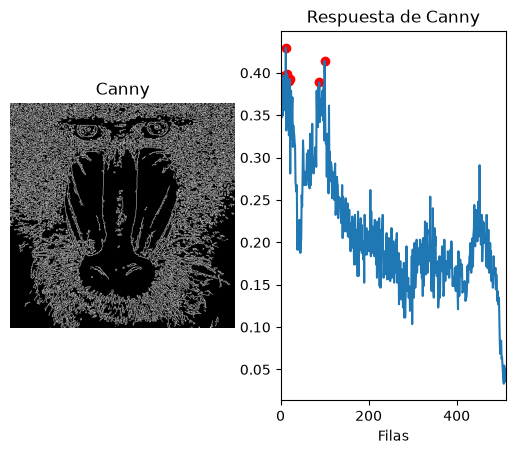

In [28]:
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Normaliza en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
# El resultado será el número de píxeles blancos por fila
rows = []
for i in range(canny.shape[0]):
    rows.append(row_counts[i] / (255 * canny.shape[1]))

maxfil = max(rows)

max_values_canny = []
max_indices_canny = []

for i, value in enumerate(rows):
    if value >= (maxfil * 0.9):
        max_values_canny.append(value)
        max_indices_canny.append(i)

    

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
plt.scatter(max_indices_canny, max_values_canny, color='red')

#Rango en x definido por las filas
plt.xlim([0, canny.shape[0]])

Esta celda contiene el código necesario para generar la imagen Sobel y su conversión a byte, que será usada en la siguiente tarea.

In [29]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

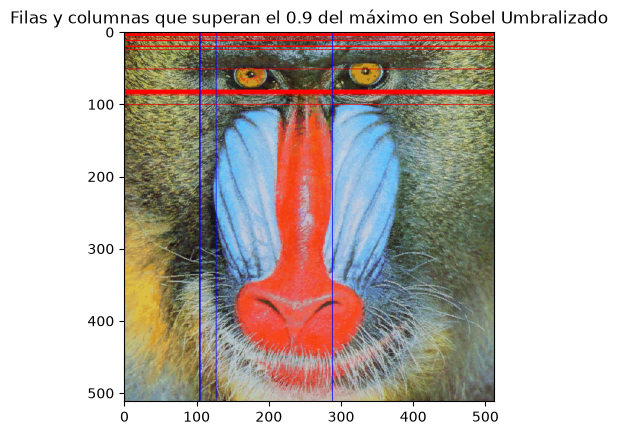

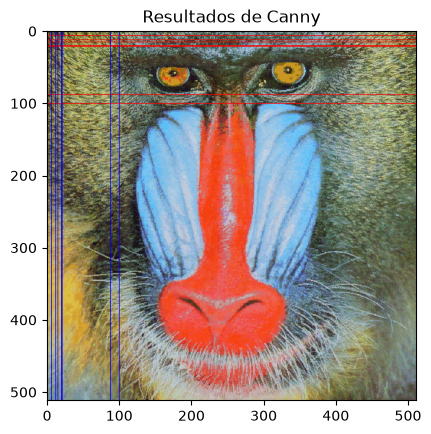

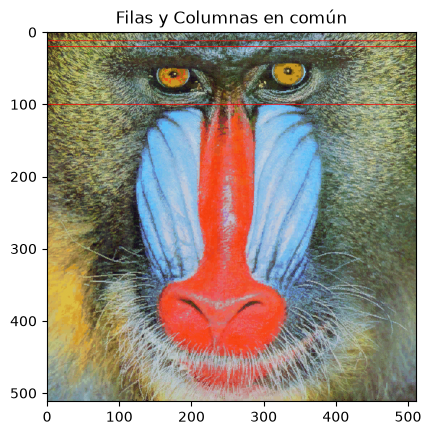

In [30]:
# Umbralizar

#Define valor umbral
valorUmbral = 100 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

#conteo de filas y columnas
col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols = col_counts[0] / (255 * imagenUmbralizada.shape[0])


row_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows = []
for i in range(imagenUmbralizada.shape[0]):
    rows.append(row_counts[i][0] / (255 * imagenUmbralizada.shape[1]))

#máximos
max_col = max(cols) 
max_row = max(rows)

#quedarnos con los que superan el 0.9 de los máximos

#filas

max_values_row = []
max_indices_row = []

for i, value in enumerate(rows):
    if value >= (max_row * 0.9):
        max_values_row.append(value)
        max_indices_row.append(i)


#columnas

max_values_col = []
max_indices_col = []

for i, value in enumerate(cols):
    if value >= (max_col * 0.9):
        max_values_col.append(value)
        max_indices_col.append(i)

imagen_original = cv2.cvtColor(cv2.imread('mandril.jpg'), cv2.COLOR_BGR2RGB)

color_col = [255, 0, 0]
color_row = [0, 0, 255]


img1 = imagen_original.copy()
img1[max_indices_row, :] = color_col
img1[:, max_indices_col] = color_row


plt.imshow(img1)
plt.title('Filas y columnas que superan el 0.9 del máximo en Sobel Umbralizado')

plt.show()


img2 = imagen_original.copy()
img2[max_indices_canny, :] = color_col
img2[:, max_indices_canny] = color_row


plt.imshow(img2)
plt.title('Resultados de Canny')

plt.show()

row_com = sorted(set(max_indices_row).intersection(set(max_indices_canny)))
col_com = sorted(set(max_indices_col).intersection(set(max_indices_canny)))

imagen_original[row_com, :] = color_col
imagen_original[:, col_com] = color_row

plt.imshow(imagen_original)
plt.title('Filas y Columnas en común')

plt.show()



TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:
vid = cv2.VideoCapture(0)

# Cargar imagen para superponer
cortina = cv2.imread('cortina.png', cv2.IMREAD_UNCHANGED)
alto_img, ancho_img = cortina.shape[:2]

disponible = 0

while True:

    # Fotograma a fotograma
    ret, frame = vid.read()

    if ret:

        if disponible > 0:

            # Diferencia entre fotogramas
            dif = cv2.absdiff(frame, pframe)

            # Pasar a escala de grises
            gris = cv2.cvtColor(dif, cv2.COLOR_BGR2GRAY)

            # Umbralizar
            _, mascara = cv2.threshold(
                gris,
                30,
                255,
                cv2.THRESH_BINARY
            )

            # calcular en que filas y columnas hay mayor cantidad de píxeles blancos
            #conteo de filas y columnas
            col_counts = cv2.reduce(mascara, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
            cols = col_counts[0] / (255 * mascara.shape[0])


            row_counts = cv2.reduce(mascara, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

            rows = []
            for i in range(mascara.shape[0]):
                rows.append(row_counts[i][0] / (255 * mascara.shape[1]))

            #posición de los máximos
            max_col = np.argmax(cols)
            max_row = np.argmax(rows)

            #hacer que la imagen salga centrada
            x = max_col - ancho_img // 2
            y = max_row - alto_img // 2

            x = max(0, min(x, frame.shape[1] - ancho_img))
            y = max(0, min(y, frame.shape[0] - alto_img))

            # Región del frame donde irá la cortina
            roi = frame[y:y+alto_img, x:x+ancho_img]

            # Canal alpha de la cortina
            alpha = cortina[:, :, 3] / 255.0

            # Canales BGR de la cortina
            imagen_bgr = cortina[:, :, :3]

            # Superponer
            for c in range(3):
                roi[:, :, c] = (
                    alpha * imagen_bgr[:, :, c] +
                    (1 - alpha) * roi[:, :, c]
                )


            cv2.imshow('Resultado', frame)

        else:
            disponible = 1
            print(frame.shape)

        # Copia del fotograma actual
        pframe = frame.copy()

    # ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

(447, 559, 4)
(480, 640, 3)
